# What the ESP-Gaussian reconstruction measures

Visualise the reconstructed vorticity field, its Gaussian weights, and the environmental, internal, and full PV-gradient fields for real eddies.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}


In [2]:
data = ept.load_cache()
gaussian = data[data.pv_surface_method.eq("esp_gaussian")].copy()
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
base = gaussian[gaussian.method.eq("esp_gaussian_2")].dropna(subset=["PV_grad_mag"])
examples = base.assign(rank=base.PV_grad_topo_p90_local_mag.rank(pct=True)).groupby("Cyc", group_keys=False).apply(lambda x: x.iloc[(x["rank"]-.9).abs().argsort()[:1]])

/scratch/pbs.9297483.kman.restech.unsw.edu.au/ipykernel_2402716/1596822218.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  examples = base.assign(rank=base.PV_grad_topo_p90_local_mag.rank(pct=True)).groupby("Cyc", group_keys=False).apply(lambda x: x.iloc[(x["rank"]-.9).abs().argsort()[:1]])


In [7]:
local

,i,j,x,y,rho_over_Rc,weight,zeta,PV,environment_east,environment_north,environment_mag,eddy_east,eddy_north,eddy_mag,full_east,full_north,full_mag
0,47,22,131.282020,108.425353,1.411287,0.136459,-0.000004,-8.846919e-07,1.150306e-11,-2.741221e-11,2.972793e-11,-7.334269e-13,-1.090052e-13,7.414830e-13,1.076963e-11,-2.752122e-11,2.955338e-11
1,47,23,131.282020,113.354937,1.408736,0.137444,-0.000004,-1.008841e-06,1.334007e-11,-3.645432e-11,3.881848e-11,-8.374504e-13,-8.104116e-16,8.374508e-13,1.250262e-11,-3.645513e-11,3.853948e-11
2,47,24,131.282020,118.284622,1.411221,0.136484,-0.000004,-1.186815e-06,1.563380e-11,-5.181592e-11,5.412306e-11,-9.731256e-13,1.446296e-13,9.838146e-13,1.466067e-11,-5.167129e-11,5.371087e-11
3,48,20,133.859229,98.566485,1.413544,0.135592,-0.000004,-5.874649e-07,1.264666e-11,-3.610550e-11,3.825631e-11,-4.832237e-13,-2.128364e-13,5.280194e-13,1.216344e-11,-3.631833e-11,3.830105e-11
4,48,21,133.859229,103.495869,1.401013,0.140459,-0.000004,-7.467961e-07,1.043922e-11,-3.417991e-11,3.573854e-11,-6.318416e-13,-1.862258e-13,6.587138e-13,9.807378e-12,-3.436613e-11,3.573815e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3716,186,23,535.341908,113.354937,1.403612,0.139439,-0.000004,-2.177957e-08,7.894892e-15,6.640245e-14,6.687014e-14,1.779237e-14,9.494773e-15,2.016728e-14,2.568726e-14,7.589723e-14,8.012630e-14
3717,187,18,539.597374,88.708018,1.404988,0.138902,-0.000004,-2.218880e-08,5.572132e-14,-5.425112e-14,7.776920e-14,1.777004e-14,-3.713213e-15,1.815385e-14,7.349135e-14,-5.796433e-14,9.359938e-14
3718,187,19,539.597374,93.637201,1.400510,0.140658,-0.000004,-2.232298e-08,5.139912e-14,-3.494364e-14,6.215245e-14,1.822899e-14,-1.051495e-15,1.825929e-14,6.962811e-14,-3.599513e-14,7.838191e-14
3719,187,20,539.597374,98.566485,1.401094,0.140428,-0.000004,-2.234864e-08,4.278351e-14,-9.503282e-15,4.382626e-14,1.835666e-14,1.681963e-15,1.843355e-14,6.114017e-14,-7.821319e-15,6.163840e-14


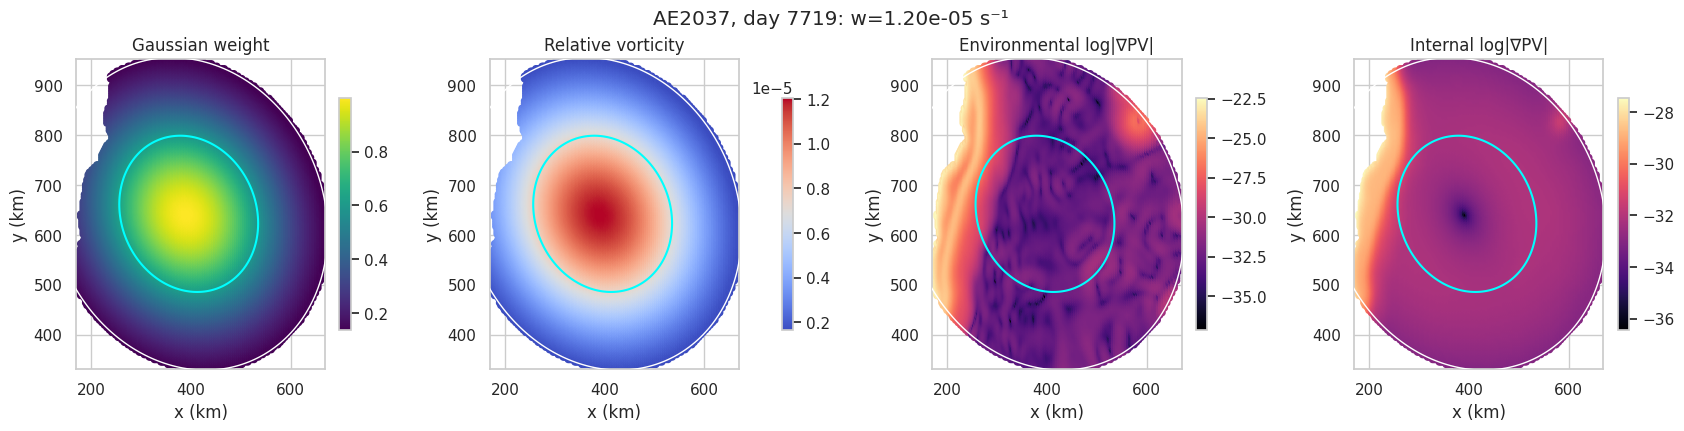

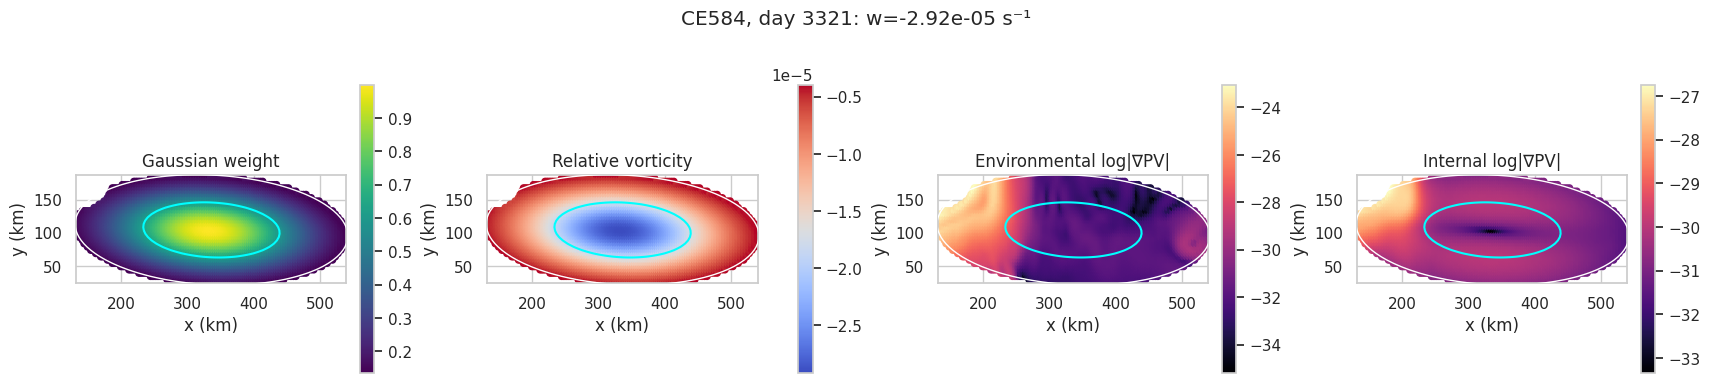

In [8]:
for _, row in examples.iterrows():
    local = ept.local_esp_fields(row, grid, frac=2)
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
    panels = [("weight","viridis","Gaussian weight"),("zeta","coolwarm","Relative vorticity"),
              ("environment_mag","magma","Environmental log|∇PV|"),("eddy_mag","magma","Internal log|∇PV|")]
    for ax, (column, cmap, title) in zip(axes, panels):
        if column in ['environment_mag', 'eddy_mag']:
            artist = ax.scatter(local.x, local.y, c=np.log(local[column]), s=20, cmap=cmap)
        else:
            artist = ax.scatter(local.x, local.y, c=local[column], s=20, cmap=cmap)
        tilt.plot_ellipse(ax, row, grid, frac=1, color="cyan", lw=1.5, zorder=10)
        tilt.plot_ellipse(ax, row, grid, frac=2, color="white", lw=1, zorder=10)
        xmin, xmax, ymin, ymax = local.x.min(), local.x.max(), local.y.min(), local.y.max()
        ax.set(aspect="equal", title=title, xlabel="x (km)", ylabel="y (km)", xlim=(xmin,xmax), ylim=(ymin,ymax))
        fig.colorbar(artist, ax=ax, shrink=.75)
    fig.suptitle(f"{row.Cyc}{int(row.Eddy)}, day {int(row.Day)}: w={row.w:.2e} s⁻¹")
    plt.show()

The cyan ellipse is the original `frac=1` core. The white ellipse is the numerical truncation at `frac=2`; cells farther away receive very small weights.